<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['coverages', 'test', 'train', 'x_left_lower_corner', 'Nx', 'y_left_lower_corner', 'Ny', 'grid_size'])

Train shape: (1624,)
Test shape: (620,)

Train dtype:
[('species', 'S22'), ('dd long', '<f4'), ('dd lat', '<f4')]

First 5 training rows:
[(b'microryzomys_minutus', -64.7   , -17.85  )
 (b'microryzomys_minutus', -67.8333, -16.3333)
 (b'microryzomys_minutus', -67.8833, -16.3   )
 (b'microryzomys_minutus', -67.8   , -16.2667)
 (b'microryzomys_minutus', -67.9833, -15.9   )]

Training DataFrame head:
                   species    dd long     dd lat
0  b'microryzomys_minutus' -64.699997 -17.850000
1  b'microryzomys_minutus' -67.833298 -16.333300
2  b'microryzomys_minutus' -67.883301 -16.299999
3  b'microryzomys_minutus' -67.800003 -16.266701
4  b'microryzomys_minutus' -67.983299 -15.900000

Species counts:
species
b'bradypus_variegatus'       116
b'microryzomys_minutus'       88
b'bradypus_variegatus_0'      81
b'bradypus_variegatus_9'      8

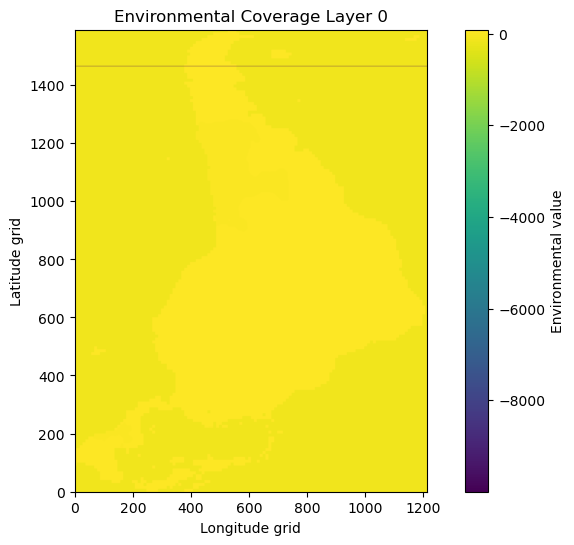

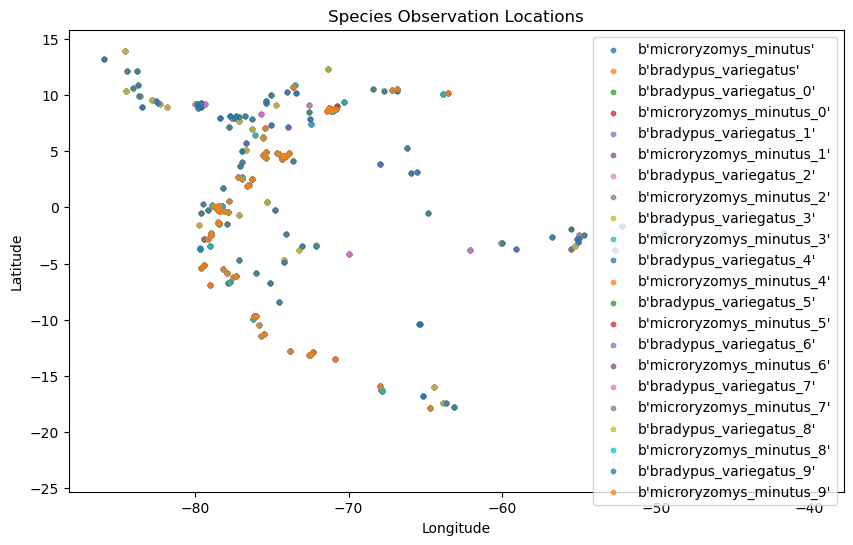


Layer 0 statistics:
Min: -9999
Max: 85
Mean: -64.9919798041362
Std: 265.5150897571478

Layer 1 statistics:
Min: -9999
Max: 179
Mean: -6332.481834191585
Std: 4860.362109970753

Layer 2 statistics:
Min: -9999
Max: 15
Mean: -88.20724445246032
Std: 256.71354498700947

Nx: 1212
Ny: 1592
Grid size: 0.05

Lower-left corner:
Longitude: -94.8
Latitude: -56.05


In [1]:
from sklearn.datasets import fetch_species_distributions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Load the dataset
# -------------------------------------------------------------------
data = fetch_species_distributions()

# -------------------------------------------------------------------
# Inspect dataset structure
# -------------------------------------------------------------------
print(type(data))
print(data.keys())

# Typical keys:
# ['coverages', 'train', 'test', 'Nx', 'Ny',
#  'x_left_lower_corner', 'y_left_lower_corner', 'grid_size']

# -------------------------------------------------------------------
# Explore train/test occurrence records
# -------------------------------------------------------------------
train = data["train"]
test = data["test"]

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain dtype:")
print(train.dtype)

print("\nFirst 5 training rows:")
print(train[:5])

# Convert to pandas DataFrame for easier inspection
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)

print("\nTraining DataFrame head:")
print(train_df.head())

print("\nSpecies counts:")
print(train_df["species"].value_counts())

# -------------------------------------------------------------------
# Coverage layers
# -------------------------------------------------------------------
coverages = data["coverages"]

print("\nCoverage array shape:")
print(coverages.shape)

# Shape is typically:
# (num_environmental_layers, Ny, Nx)

n_layers, ny, nx = coverages.shape

print(f"\nLayers: {n_layers}")
print(f"Grid size: {ny} x {nx}")

# -------------------------------------------------------------------
# Visualize one environmental layer
# -------------------------------------------------------------------
layer_index = 0

plt.figure(figsize=(10, 6))
plt.imshow(coverages[layer_index], origin="lower")
plt.colorbar(label="Environmental value")
plt.title(f"Environmental Coverage Layer {layer_index}")
plt.xlabel("Longitude grid")
plt.ylabel("Latitude grid")
plt.show()

# -------------------------------------------------------------------
# Plot species observation locations
# -------------------------------------------------------------------
species_names = train_df["species"].unique()

plt.figure(figsize=(10, 6))

for species in species_names:
    subset = train_df[train_df["species"] == species]

    plt.scatter(
        subset["dd long"],
        subset["dd lat"],
        s=10,
        label=species,
        alpha=0.7
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Species Observation Locations")
plt.legend()
plt.show()

# -------------------------------------------------------------------
# Basic statistics for coverage layers
# -------------------------------------------------------------------
for i in range(min(3, n_layers)):
    layer = coverages[i]

    print(f"\nLayer {i} statistics:")
    print("Min:", np.nanmin(layer))
    print("Max:", np.nanmax(layer))
    print("Mean:", np.nanmean(layer))
    print("Std:", np.nanstd(layer))

# -------------------------------------------------------------------
# Metadata
# -------------------------------------------------------------------
print("\nNx:", data["Nx"])
print("Ny:", data["Ny"])
print("Grid size:", data["grid_size"])

print("\nLower-left corner:")
print("Longitude:", data["x_left_lower_corner"])
print("Latitude:", data["y_left_lower_corner"])

In [2]:
train_df

,species,dd long,dd lat
0,b'microryzomys_minutus',-64.699997,-17.850000
1,b'microryzomys_minutus',-67.833298,-16.333300
2,b'microryzomys_minutus',-67.883301,-16.299999
3,b'microryzomys_minutus',-67.800003,-16.266701
4,b'microryzomys_minutus',-67.983299,-15.900000
...,...,...,...
1619,b'microryzomys_minutus_9',-78.500000,-1.300000
1620,b'microryzomys_minutus_9',-78.133301,-0.366670
1621,b'microryzomys_minutus_9',-78.466698,-0.300000
1622,b'microryzomys_minutus_9',-77.816704,0.600000


________________________________________________________________________________
Modeling distribution of species 'bradypus variegatus'
 - fit OneClassSVM ... done.
 - plot coastlines from coverage
 - predict species distribution

 Area under the ROC curve : 0.868443
________________________________________________________________________________
Modeling distribution of species 'microryzomys minutus'
 - fit OneClassSVM ... done.
 - plot coastlines from coverage
 - predict species distribution

 Area under the ROC curve : 0.993919

time elapsed: 3.55s


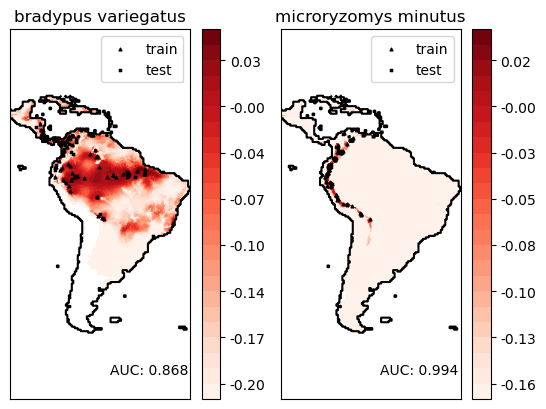

In [3]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

from time import time

import matplotlib.pyplot as plt
import numpy as np

from sklearn import metrics, svm
from sklearn.datasets import fetch_species_distributions
from sklearn.utils import Bunch

# if basemap is available, we'll use it.
# otherwise, we'll improvise later...
try:
    from mpl_toolkits.basemap import Basemap

    basemap = True
except ImportError:
    basemap = False


def construct_grids(batch):
    """Construct the map grid from the batch object

    Parameters
    ----------
    batch : Batch object
        The object returned by :func:`fetch_species_distributions`

    Returns
    -------
    (xgrid, ygrid) : 1-D arrays
        The grid corresponding to the values in batch.coverages
    """
    # x,y coordinates for corner cells
    xmin = batch.x_left_lower_corner + batch.grid_size
    xmax = xmin + (batch.Nx * batch.grid_size)
    ymin = batch.y_left_lower_corner + batch.grid_size
    ymax = ymin + (batch.Ny * batch.grid_size)

    # x coordinates of the grid cells
    xgrid = np.arange(xmin, xmax, batch.grid_size)
    # y coordinates of the grid cells
    ygrid = np.arange(ymin, ymax, batch.grid_size)

    return (xgrid, ygrid)


def create_species_bunch(species_name, train, test, coverages, xgrid, ygrid):
    """Create a bunch with information about a particular organism

    This will use the test/train record arrays to extract the
    data specific to the given species name.
    """
    bunch = Bunch(name=" ".join(species_name.split("_")[:2]))
    species_name = species_name.encode("ascii")
    points = dict(test=test, train=train)

    for label, pts in points.items():
        # choose points associated with the desired species
        pts = pts[pts["species"] == species_name]
        bunch["pts_%s" % label] = pts

        # determine coverage values for each of the training & testing points
        ix = np.searchsorted(xgrid, pts["dd long"])
        iy = np.searchsorted(ygrid, pts["dd lat"])
        bunch["cov_%s" % label] = coverages[:, -iy, ix].T

    return bunch


def plot_species_distribution(
    species=("bradypus_variegatus_0", "microryzomys_minutus_0"),
):
    """
    Plot the species distribution.
    """
    if len(species) > 2:
        print(
            "Note: when more than two species are provided,"
            " only the first two will be used"
        )

    t0 = time()

    # Load the compressed data
    data = fetch_species_distributions()

    # Set up the data grid
    xgrid, ygrid = construct_grids(data)

    # The grid in x,y coordinates
    X, Y = np.meshgrid(xgrid, ygrid[::-1])

    # create a bunch for each species
    BV_bunch = create_species_bunch(
        species[0], data.train, data.test, data.coverages, xgrid, ygrid
    )
    MM_bunch = create_species_bunch(
        species[1], data.train, data.test, data.coverages, xgrid, ygrid
    )

    # background points (grid coordinates) for evaluation
    np.random.seed(13)
    background_points = np.c_[
        np.random.randint(low=0, high=data.Ny, size=10000),
        np.random.randint(low=0, high=data.Nx, size=10000),
    ].T

    # We'll make use of the fact that coverages[6] has measurements at all
    # land points.  This will help us decide between land and water.
    land_reference = data.coverages[6]

    # Fit, predict, and plot for each species.
    for i, species in enumerate([BV_bunch, MM_bunch]):
        print("_" * 80)
        print("Modeling distribution of species '%s'" % species.name)

        # Standardize features
        mean = species.cov_train.mean(axis=0)
        std = species.cov_train.std(axis=0)
        train_cover_std = (species.cov_train - mean) / std

        # Fit OneClassSVM
        print(" - fit OneClassSVM ... ", end="")
        clf = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.5)
        clf.fit(train_cover_std)
        print("done.")

        # Plot map of South America
        plt.subplot(1, 2, i + 1)
        if basemap:
            print(" - plot coastlines using basemap")
            m = Basemap(
                projection="cyl",
                llcrnrlat=Y.min(),
                urcrnrlat=Y.max(),
                llcrnrlon=X.min(),
                urcrnrlon=X.max(),
                resolution="c",
            )
            m.drawcoastlines()
            m.drawcountries()
        else:
            print(" - plot coastlines from coverage")
            plt.contour(
                X, Y, land_reference, levels=[-9998], colors="k", linestyles="solid"
            )
            plt.xticks([])
            plt.yticks([])

        print(" - predict species distribution")

        # Predict species distribution using the training data
        Z = np.ones((data.Ny, data.Nx), dtype=np.float64)

        # We'll predict only for the land points.
        idx = (land_reference > -9999).nonzero()
        coverages_land = data.coverages[:, idx[0], idx[1]].T

        pred = clf.decision_function((coverages_land - mean) / std)
        Z *= pred.min()
        Z[idx[0], idx[1]] = pred

        levels = np.linspace(Z.min(), Z.max(), 25)
        Z[land_reference == -9999] = -9999

        # plot contours of the prediction
        plt.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
        plt.colorbar(format="%.2f")

        # scatter training/testing points
        plt.scatter(
            species.pts_train["dd long"],
            species.pts_train["dd lat"],
            s=2**2,
            c="black",
            marker="^",
            label="train",
        )
        plt.scatter(
            species.pts_test["dd long"],
            species.pts_test["dd lat"],
            s=2**2,
            c="black",
            marker="x",
            label="test",
        )
        plt.legend()
        plt.title(species.name)
        plt.axis("equal")

        # Compute AUC with regards to background points
        pred_background = Z[background_points[0], background_points[1]]
        pred_test = clf.decision_function((species.cov_test - mean) / std)
        scores = np.r_[pred_test, pred_background]
        y = np.r_[np.ones(pred_test.shape), np.zeros(pred_background.shape)]
        fpr, tpr, thresholds = metrics.roc_curve(y, scores)
        roc_auc = metrics.auc(fpr, tpr)
        plt.text(-35, -70, "AUC: %.3f" % roc_auc, ha="right")
        print("\n Area under the ROC curve : %f" % roc_auc)

    print("\ntime elapsed: %.2fs" % (time() - t0))


plot_species_distribution()
plt.show()

In [4]:
train_cover_std

NameError: name 'train_cover_std' is not defined

In [7]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [8]:
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import l1_min_c

cs = l1_min_c(X, y, loss="log") * np.logspace(0, 1, 16)

In [ ]:
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        tol=1e-6,
        max_iter=int(1e6),
        warm_start=True,
        fit_intercept=False,
    ),
)
coefs_ = []
for c in cs:
    clf.set_params(logisticregression__C=c)
    clf.fit(X, y)
    coefs_.append(clf["logisticregression"].coef_.ravel().copy())

coefs_ = np.array(coefs_)import matplotlib.pyplot as plt

# Colorblind-friendly palette (IBM Color Blind Safe palette)
colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100"]

plt.figure(figsize=(10, 6))
for i in range(coefs_.shape[1]):
    plt.semilogx(cs, coefs_[:, i], marker="o", color=colors[i], label=feature_names[i])

ymin, ymax = plt.ylim()
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend()
plt.axis("tight")
plt.show()

In [10]:
import json

# Open and load JSON file
with open("/Users/dybl4375/Desktop/waterquality.json", "r") as f:
    data = json.load(f)

# Print the loaded object
print(data)

# Example access
# print(data["key"])

{'data_set_description': {'id': '46085', 'name': 'Water_Quality', 'version': '1', 'description': 'Description:\nThe dataset named "water-quality-1.csv" comprises a comprehensive collection of water quality measurements from various sites, meticulously recorded to monitor environmental health and pollution levels. It encompasses a diverse range of parameters such as Fecal Coliform, Conductivity Field, Temperature, Total Nitrogen, and Nitrite + Nitrate Nitrogen, crucial for assessing water quality in ecosystems. The data spans multiple years, offering insights into temporal changes affecting water bodies.\n\nAttribute Description:\n- Sample ID: Unique identifier for each sample (e.g., 58086).\n- Grab ID: Identifier for the specific collection instance, with some entries missing.\n- Profile ID: Unique profile number associated with each sample site (e.g., 46937).\n- Sample Number: A distinct code for each sample, combining letters and numbers (e.g., \'L47270-122\').\n- Collect DateTime: D

In [96]:
json_path = "/Users/dybl4375/Documents/Teaching/GEOL 599 - Machine Learning/Machine_Learning_Course_Code_and_Data/Data/waterquality.json"

with open(json_path, "r") as f:
    meta = json.load(f)["data_set_description"]

meta_df = pd.DataFrame([meta])
print("Metadata:")
print(meta_df.T)

# ----------------------------
# 2) Load the actual dataset
#    Prefer Parquet because it's easier than ARFF
# ----------------------------
parquet_url = meta["parquet_url"]
df = pd.read_parquet(parquet_url)

print("\nRaw data shape:", df.shape)
print(df.head())

Metadata:
                                                                     0
id                                                               46085
name                                                     Water_Quality
version                                                              1
description          Description:\nThe dataset named "water-quality...
description_version                                                  1
format                                                            arff
creator                                                           None
contributor                                     Sukhmandeep Singh Brar
collection_date                                             19-04-2024
upload_date                                        2024-05-31T14:11:55
language                                                       English
licence                                            Public Domain (CC0)
url                  https://openml.org/data/v1/download/22120529/W

In [97]:
df

,Sample ID,Grab ID,Profile ID,Sample Number,Collect DateTime,Depth (m),Site Type,Area,Locator,Site,...,MDL,RDL,Text Value,Sample Info,Steward Note,Replicates,Replicate Of,Method,Date Analyzed,Data Source
0,16316,16316.0,10702,9209019,04/13/1992 12:00:00 AM,1.0,Streams and Rivers,Pipers,KSHZ06,Pipers Creek mouth,...,NaN,NaN,.070||King County Nstream Database/B53311,None,None,NaN,NaN,none,None,KCEL
1,8937,8937.0,37688,7915489,06/20/1979 12:00:00 AM,1.0,Streams and Rivers,Crisp,0321,Crisp Creek mouth at SE Green Valley Rd,...,NaN,NaN,.727||King County Nstream Database/RS2,None,None,NaN,NaN,None,None,KCEL
2,137745,137745.0,54368,L58228-1,06/25/2013 08:09:00 AM,1.0,Large Lakes,Lake Union/Ship Canal,0512,Ship Canal above locks,...,NaN,NaN,None,None,None,NaN,NaN,HYDROLAB,06/25/2013,KCEL
3,131816,131816.0,50605,L55068-6,02/13/2012 09:38:00 AM,1.0,Large Lakes,Lake Union/Ship Canal,0540,Ship Canal near Montlake Bridge,...,0.002,0.005,None,None,None,NaN,NaN,SM4500-P-F,02/15/2012,KCEL
4,82325,82325.0,43896,L52933-87,03/30/2011 02:36:00 PM,4.2,Large Lakes,Lake Washington,0804,Lake Washington north end,...,NaN,NaN,None,None,None,NaN,NaN,HYDROLAB,None,KCEL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1259439,185419,185419.0,78924,L73423-26,10/21/2019 10:38:00 AM,25.0,Marine Offshore,Central Puget Sound,KSSK02,West Point Outfall,...,0.060,0.120,None,None,None,NaN,NaN,CTD,10/21/2019,KCEL
1259440,185252,185252.0,78914,L73423-34,10/21/2019 11:45:00 AM,25.0,Marine Offshore,Central Puget Sound,LTED04,South Central Elliott Bay,...,NaN,NaN,None,None,None,NaN,NaN,CTD,10/21/2019,KCEL
1259441,184301,184301.0,78849,L73423-17,10/21/2019 09:57:00 AM,14.8,Marine Offshore,Central Puget Sound,JSUR01,Point Wells,...,NaN,NaN,None,None,None,NaN,NaN,CTD,10/21/2019,KCEL
1259442,183766,183766.0,78821,L73428-35,10/22/2019 01:09:00 PM,100.0,Marine Offshore,Central Puget Sound,NSEX01,East Passage,...,0.500,1.000,None,None,None,NaN,NaN,CTD,10/22/2019,KCEL


Metadata:
                                                                     0
id                                                               46085
name                                                     Water_Quality
version                                                              1
description          Description:\nThe dataset named "water-quality...
description_version                                                  1
format                                                            arff
creator                                                           None
contributor                                     Sukhmandeep Singh Brar
collection_date                                             19-04-2024
upload_date                                        2024-05-31T14:11:55
language                                                       English
licence                                            Public Domain (CC0)
url                  https://openml.org/data/v1/download/22120529/W

/var/folders/ky/9n8k4hcs4wx4_32prby4vn6w0000gn/T/ipykernel_26820/2325302299.py:64: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")
/var/folders/ky/9n8k4hcs4wx4_32prby4vn6w0000gn/T/ipykernel_26820/2325302299.py:69: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")



Shape: (1259444, 25)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259444 entries, 0 to 1259443
Data columns (total 25 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   sample_id         1259444 non-null  int64         
 1   grab_id           882666 non-null   float64       
 2   profile_id        1259444 non-null  int64         
 3   sample_number     1259444 non-null  object        
 4   collect_datetime  1259444 non-null  datetime64[ns]
 5   depth_m           882666 non-null   float64       
 6   site_type         1259444 non-null  object        
 7   area              1259311 non-null  object        
 8   locator           1259444 non-null  object        
 9   site              1259444 non-null  object        
 10  parameter         1259444 non-null  object        
 11  value             1150359 non-null  float64       
 12  units             1258664 non-null  object        
 13  qualityid    

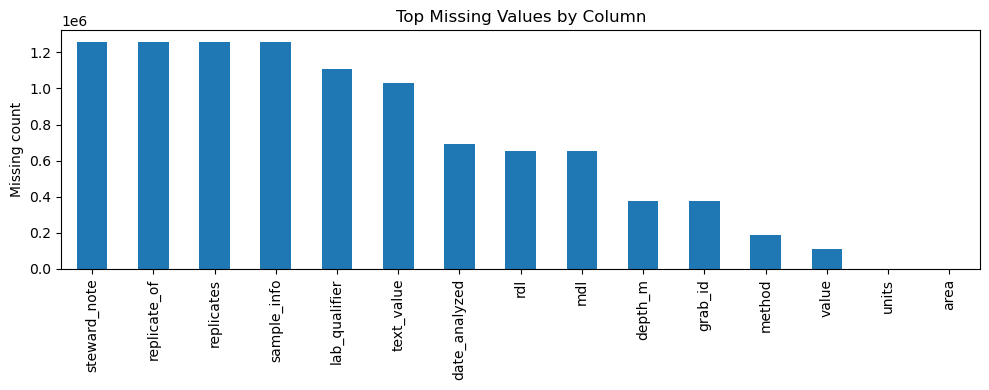

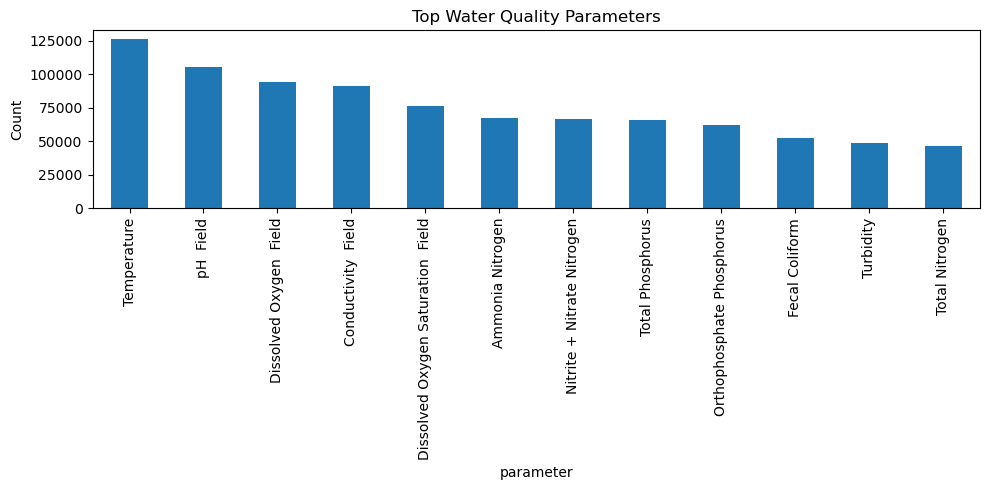

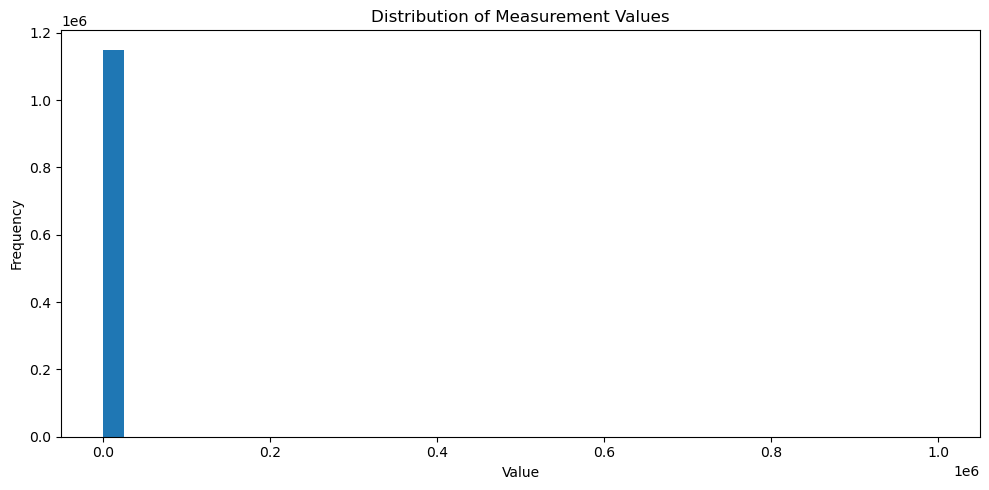

<Figure size 1200x500 with 0 Axes>

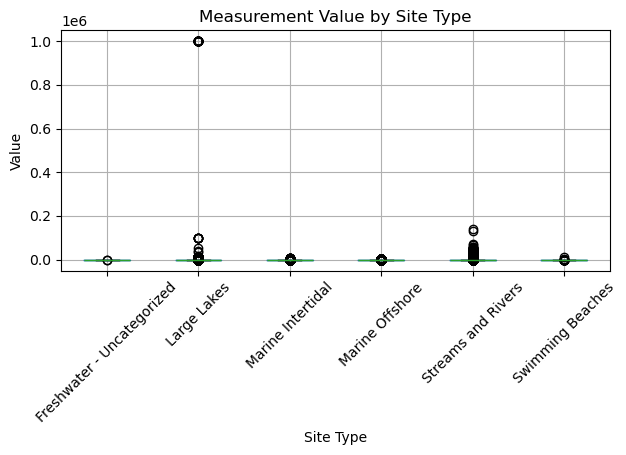

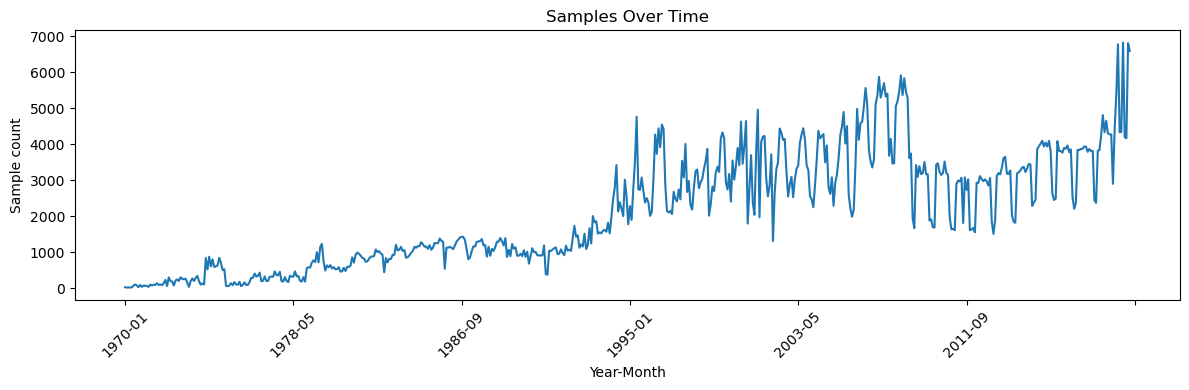

In [11]:
import json
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------
# 1) Load the JSON metadata
# ----------------------------
json_path = "/Users/dybl4375/Desktop/waterquality.json"

with open(json_path, "r") as f:
    meta = json.load(f)["data_set_description"]

meta_df = pd.DataFrame([meta])
print("Metadata:")
print(meta_df.T)

# ----------------------------
# 2) Load the actual dataset
#    Prefer Parquet because it's easier than ARFF
# ----------------------------
parquet_url = meta["parquet_url"]

try:
    df = pd.read_parquet(parquet_url)
except Exception:
    # Fallback: download first, then read
    tmp_path = Path(tempfile.gettempdir()) / "water_quality.parquet"
    r = requests.get(parquet_url, timeout=60)
    r.raise_for_status()
    tmp_path.write_bytes(r.content)
    df = pd.read_parquet(tmp_path)

print("\nRaw data shape:", df.shape)
print(df.head())

# ----------------------------
# 3) Clean column names
# ----------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
    .str.strip("_")
)

print("\nCleaned columns:")
print(df.columns.tolist())

# ----------------------------
# 4) Basic cleaning / type conversion
# ----------------------------
date_cols = [c for c in df.columns if "date" in c or "time" in c]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Try to convert obvious numeric columns
for c in df.columns:
    if c not in date_cols:
        df[c] = pd.to_numeric(df[c], errors="ignore")

# Common columns from this dataset after cleaning:
# sample_id, grab_id, profile_id, sample_number, collect_datetime, depth_m,
# site_type, area, locator, site, parameter, value, units, qualityid, ...

# ----------------------------
# 5) Explore the data
# ----------------------------
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values (top 15):")
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(15))

print("\nNumeric summary:")
print(df.select_dtypes(include="number").describe().T)

print("\nCategorical summary:")
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for c in cat_cols[:5]:
    print(f"\n{c} value counts:")
    print(df[c].value_counts(dropna=False).head(10))

# ----------------------------
# 6) Feature engineering for ML
#    Drop pure identifiers, keep meaningful features
# ----------------------------
id_like = [
    c for c in [
        "sample_id", "grab_id", "profile_id", "sample_number",
        "locator"
    ] if c in df.columns
]

# Example target choices:
# - Regression: target_col = "value"
# - Classification: target_col = "parameter" or "site_type"
target_col = "value" if "value" in df.columns else None

# If you want supervised learning, set target_col manually here:
# target_col = "parameter"

if target_col is not None:
    data_ml = df.copy()

    # Keep rows where target exists
    data_ml = data_ml.dropna(subset=[target_col])

    X = data_ml.drop(columns=[target_col] + id_like, errors="ignore")
    y = data_ml[target_col]

    numeric_features = X.select_dtypes(include=["number", "float64", "int64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features),
        ],
        remainder="drop",
    )

    X_prepared = preprocess.fit_transform(X)
    print("\nML matrix shape:", X_prepared.shape)
    print("Target shape:", y.shape)
else:
    print("\nNo target column set. Set target_col manually for supervised ML.")

# ----------------------------
# 7) Plots
# ----------------------------

# Plot 1: Missing values
plt.figure(figsize=(10, 4))
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(15)
missing.plot(kind="bar")
plt.title("Top Missing Values by Column")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

# Plot 2: Most common parameters (if present)
if "parameter" in df.columns:
    plt.figure(figsize=(10, 5))
    df["parameter"].value_counts().head(12).plot(kind="bar")
    plt.title("Top Water Quality Parameters")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot 3: Distribution of Value (if present)
if "value" in df.columns:
    plt.figure(figsize=(10, 5))
    vals = pd.to_numeric(df["value"], errors="coerce").dropna()
    plt.hist(vals, bins=40)
    plt.title("Distribution of Measurement Values")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot 4: Value by site type (if present)
if "site_type" in df.columns and "value" in df.columns:
    tmp = df[["site_type", "value"]].copy()
    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["site_type", "value"])

    top_sites = tmp["site_type"].value_counts().head(8).index
    tmp = tmp[tmp["site_type"].isin(top_sites)]

    plt.figure(figsize=(12, 5))
    tmp.boxplot(column="value", by="site_type", rot=45)
    plt.title("Measurement Value by Site Type")
    plt.suptitle("")
    plt.xlabel("Site Type")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# Plot 5: Samples over time (if datetime present)
if "collect_datetime" in df.columns:
    ts = df.dropna(subset=["collect_datetime"]).copy()
    ts["year_month"] = ts["collect_datetime"].dt.to_period("M").astype(str)
    counts = ts["year_month"].value_counts().sort_index()

    plt.figure(figsize=(12, 4))
    counts.plot()
    plt.title("Samples Over Time")
    plt.xlabel("Year-Month")
    plt.ylabel("Sample count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
df.columns

Index(['sample_id', 'grab_id', 'profile_id', 'sample_number',
       'collect_datetime', 'depth_m', 'site_type', 'area', 'locator', 'site',
       'parameter', 'value', 'units', 'qualityid', 'lab_qualifier', 'mdl',
       'rdl', 'text_value', 'sample_info', 'steward_note', 'replicates',
       'replicate_of', 'method', 'date_analyzed', 'data_source'],
      dtype='object')

In [19]:
# Keep only needed columns
tmp = df[['collect_datetime', 'locator', 'parameter', 'value']].copy()

# Ensure numeric values
tmp['value'] = pd.to_numeric(tmp['value'], errors='coerce')

# Pivot wider:
# rows    -> collect_datetime + locator
# columns -> parameter
# values  -> value
wide_df = tmp.pivot_table(
    index=['collect_datetime', 'locator'],
    columns='parameter',
    values='value',
    aggfunc='mean'   # use mean if duplicates exist
).reset_index()

wide_df

parameter,collect_datetime,locator,Ammonia Nitrogen,BGA PC Field,Biochemical Oxygen Demand,Chlorophyll Field,Chlorophyll a,Conductivity,Conductivity Field,Density,...,Total Kjeldahl Nitrogen,Total Nitrogen,Total Organic Carbon,Total Phosphorus,Total Suspended Solids,Turbidity,Turbidity Field,Volatile Suspended Solids,pH,pH Field
0,1970-01-03 00:00:00,KTHA01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-05 00:00:00,KSSN04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1970-01-05 00:00:00,KSSN05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1970-01-05 00:00:00,KTHA01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1970-01-08 00:00:00,KTHA01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121402,2019-10-30 10:51:00,SAMMBUOY,NaN,NaN,NaN,0.52,NaN,NaN,114.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.76
121403,2019-10-30 10:52:00,SAMMBUOY,NaN,NaN,NaN,0.58,NaN,NaN,115.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.77
121404,2019-10-30 10:53:00,SAMMBUOY,NaN,NaN,NaN,0.51,NaN,NaN,118.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.78
121405,2019-10-30 10:54:00,SAMMBUOY,NaN,NaN,NaN,0.56,NaN,NaN,119.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.80


In [35]:
df.parameter.value_counts()

parameter
Temperature                           126633
pH                                    121464
Conductivity                          114415
Dissolved Oxygen                      113670
Dissolved Oxygen Saturation  Field     76535
Ammonia Nitrogen                       67434
Nitrite + Nitrate Nitrogen             66853
Total Phosphorus                       65693
Orthophosphate Phosphorus              62222
Turbidity                              56614
Fecal Coliform                         52365
Total Nitrogen                         46158
Chlorophyll                            45702
Total Suspended Solids                 42911
Total Alkalinity                       29171
Enterococcus                           24656
Storm Or Non-Storm                     22947
Sampling Method                        17717
Chlorophyll a                          17488
Pheophytin a                           17178
BGA PC  Field                          15175
E. coli                                13163


In [62]:
ph_rows = df[df['parameter'].str.contains('Chlorophyll', case=False, na=False)]

print(ph_rows['parameter'].value_counts())

parameter
Chlorophyll a    63190
Name: count, dtype: int64


In [61]:
df['parameter'] = df['parameter'].replace({
    'pH  Field': 'pH',
    'Conductivity  Field': 'Conductivity',
    'Dissolved Oxygen  Field': 'Dissolved Oxygen',
    'Turbidity  Field': 'Turbidity',
    'Chlorophyll  Field': 'Chlorophyll a'
})

In [80]:
selected_columns = [
    'collect_datetime',
    'locator',
    'Temperature',
    'pH',
    'Conductivity',
    'Dissolved Oxygen',
    'Total Phosphorus',
    'Turbidity',
    'Total Nitrogen',
    'Chlorophyll a',
    'Total Suspended Solids'
]

# Keep only columns that actually exist
selected_columns = [c for c in selected_columns if c in wide_df.columns]

ml_df = wide_df[selected_columns].copy()

In [81]:
ml_df=ml_df.dropna(subset=['Chlorophyll a'])
ml_df=ml_df[ml_df.isna().sum(axis=1) <= 2]

In [82]:
ml_df

parameter,collect_datetime,locator,Temperature,pH,Conductivity,Dissolved Oxygen,Total Phosphorus,Turbidity,Total Nitrogen,Chlorophyll a,Total Suspended Solids
1108,1974-01-03 00:00:00,0518,6.300,6.80,88.0,10.400,NaN,2.600,NaN,5.385,3.000
1109,1974-01-03 00:00:00,0522,6.475,6.90,83.0,10.450,NaN,3.725,NaN,1.660,9.475
1110,1974-01-03 00:00:00,0526,6.450,6.80,83.0,10.450,NaN,2.050,NaN,2.980,21.000
1111,1974-01-03 00:00:00,0532,6.375,6.80,83.5,10.525,NaN,2.925,NaN,2.355,3.550
1127,1974-01-17 00:00:00,0518,6.850,6.85,83.0,11.000,NaN,2.300,NaN,0.940,3.250
...,...,...,...,...,...,...,...,...,...,...,...
49257,2003-01-06 16:10:00,A522,8.400,NaN,94.0,NaN,0.01540,0.960,0.319,3.900,1.410
49658,2003-03-03 10:11:00,A522,7.900,NaN,95.0,NaN,0.00970,0.970,0.270,8.610,2.550
49951,2003-04-07 10:26:00,A522,9.100,NaN,96.3,NaN,0.01160,1.300,0.307,12.800,3.700
50298,2003-05-05 09:37:00,A522,12.150,NaN,98.1,NaN,0.01125,1.025,0.302,6.810,1.300


In [83]:
import numpy as np

# Ensure datetime type
ml_df['collect_datetime'] = pd.to_datetime(
    ml_df['collect_datetime'],
    errors='coerce'
)

# Day of year (1–366)
ml_df['day_of_year'] = ml_df['collect_datetime'].dt.dayofyear

# Cyclical sine encoding
ml_df['day_of_year_sin'] = np.sin(
    2 * np.pi * ml_df['day_of_year'] / 365.0
)

ml_df['day_of_year_cos'] = np.cos(
    2 * np.pi * ml_df['day_of_year'] / 365.0
)

In [84]:
ml_df.columns

Index(['collect_datetime', 'locator', 'Temperature', 'pH', 'Conductivity',
       'Dissolved Oxygen', 'Total Phosphorus', 'Turbidity', 'Total Nitrogen',
       'Chlorophyll a', 'Total Suspended Solids', 'day_of_year',
       'day_of_year_sin', 'day_of_year_cos'],
      dtype='object', name='parameter')

                   column  n_test_values        MAE       RMSE
4        Total Phosphorus            185   0.007447   0.017647
6          Total Nitrogen              3   0.069533   0.073240
1                      pH            227   0.419626   0.539955
5               Turbidity            189   0.532296   0.921411
3        Dissolved Oxygen            198   0.880340   1.152145
7  Total Suspended Solids            118   1.006458   1.316918
0             Temperature            210   1.386700   1.863045
2            Conductivity            210  20.402397  50.739300


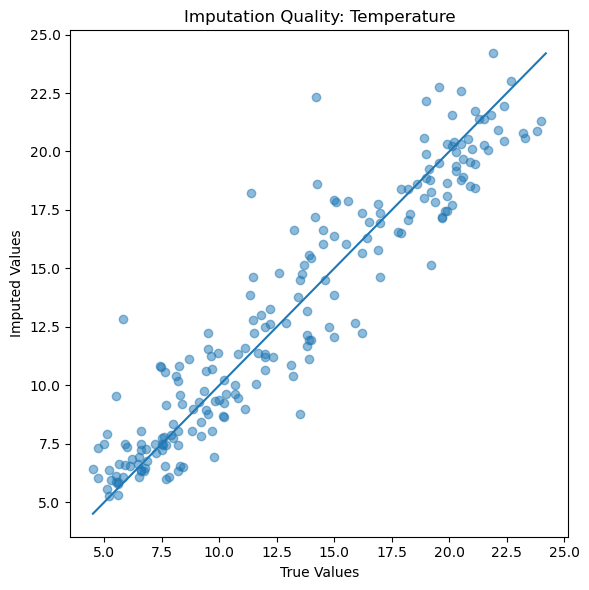


Final imputed dataset:
parameter  Temperature    pH  Conductivity  Dissolved Oxygen  \
1108             6.300  6.80          88.0            10.400   
1109             6.475  6.90          83.0            10.450   
1110             6.450  6.80          83.0            10.450   
1111             6.375  6.80          83.5            10.525   
1127             6.850  6.85          83.0            11.000   

parameter  Total Phosphorus  Turbidity  Total Nitrogen  \
1108               0.042200      2.600          0.5388   
1109               0.027633      3.725          0.5632   
1110               0.026933      2.050          0.5588   
1111               0.027667      2.925          0.5632   
1127               0.026267      2.300          0.5632   

parameter  Total Suspended Solids  day_of_year_sin  day_of_year_cos  
1108                        3.000         0.051620         0.998667  
1109                        9.475         0.051620         0.998667  
1110                       21.00

In [87]:
import numpy as np
import pandas as pd

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

data = ml_df.drop(columns=['collect_datetime', 'locator', 'Chlorophyll a', 'day_of_year'])

# ----------------------------------------------------
# Create artificial missing values
# so we can evaluate imputation quality
# ----------------------------------------------------
np.random.seed(42)

test_data = data.copy()

# Mask 10% of existing values
mask = pd.DataFrame(
    np.random.rand(*test_data.shape) < 0.10,
    columns=test_data.columns,
    index=test_data.index
)

# Only mask values that originally exist
mask = mask & test_data.notna()

# ---------------------------------
# Prevent masking these columns
# ---------------------------------
protected_cols = ['day_of_year_sin', 'day_of_year_cos']

mask[protected_cols] = False

# Save true values
true_values = test_data[mask]

# Create corrupted version
corrupted = test_data.copy()
corrupted[mask] = np.nan

# ----------------------------------------------------
# Impute missing values
# ----------------------------------------------------
imputer = KNNImputer(n_neighbors=5)

imputed_array = imputer.fit_transform(corrupted)

imputed = pd.DataFrame(
    imputed_array,
    columns=corrupted.columns,
    index=corrupted.index
)

# ----------------------------------------------------
# Evaluate imputation performance
# ----------------------------------------------------
results = []

for col in data.columns:

    col_mask = mask[col]

    if col_mask.sum() == 0:
        continue

    y_true = test_data.loc[col_mask, col]
    y_pred = imputed.loc[col_mask, col]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({
        "column": col,
        "n_test_values": col_mask.sum(),
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("RMSE"))

# ----------------------------------------------------
# Compare original vs imputed values visually
# ----------------------------------------------------
import matplotlib.pyplot as plt

example_col = "Temperature"

if example_col in data.columns:

    col_mask = mask[example_col]

    y_true = test_data.loc[col_mask, example_col]
    y_pred = imputed.loc[col_mask, example_col]

    plt.figure(figsize=(6, 6))

    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val]
    )

    plt.xlabel("True Values")
    plt.ylabel("Imputed Values")
    plt.title(f"Imputation Quality: {example_col}")

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------
# Final imputed dataset
# ----------------------------------------------------
final_imputer = KNNImputer(n_neighbors=5)

ml_df_imputed = pd.DataFrame(
    final_imputer.fit_transform(data),
    columns=data.columns,
    index=data.index
)

print("\nFinal imputed dataset:")
print(ml_df_imputed.head())

parameter,Temperature,pH,Conductivity,Dissolved Oxygen,Total Phosphorus,Turbidity,Total Nitrogen,Total Suspended Solids,day_of_year_sin,day_of_year_cos
1108,6.300,6.800000,88.0,10.400000,0.042200,2.600,0.5388,3.000,0.051620,0.998667
1109,6.475,6.900000,83.0,10.450000,0.027633,3.725,0.5632,9.475,0.051620,0.998667
1110,6.450,6.800000,83.0,10.450000,0.026933,2.050,0.5588,21.000,0.051620,0.998667
1111,6.375,6.800000,83.5,10.525000,0.027667,2.925,0.5632,3.550,0.051620,0.998667
1127,6.850,6.850000,83.0,11.000000,0.026267,2.300,0.5632,3.250,0.288482,0.957485
...,...,...,...,...,...,...,...,...,...,...
49257,8.400,7.240000,94.0,9.893333,0.015400,0.960,0.3190,1.410,0.103102,0.994671
49658,7.900,7.543333,95.0,11.556667,0.009700,0.970,0.2700,2.550,0.875892,0.482508
49951,9.100,7.980000,96.3,12.420000,0.011600,1.300,0.3070,3.700,0.995105,-0.098820
50298,12.150,7.855000,98.1,10.550000,0.011250,1.025,0.3020,1.300,0.835925,-0.548843


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': False}

Best CV RMSE: 2.1905

Held-out test set results:
MAE:  1.5190
RMSE: 2.3210
R²:   0.6128


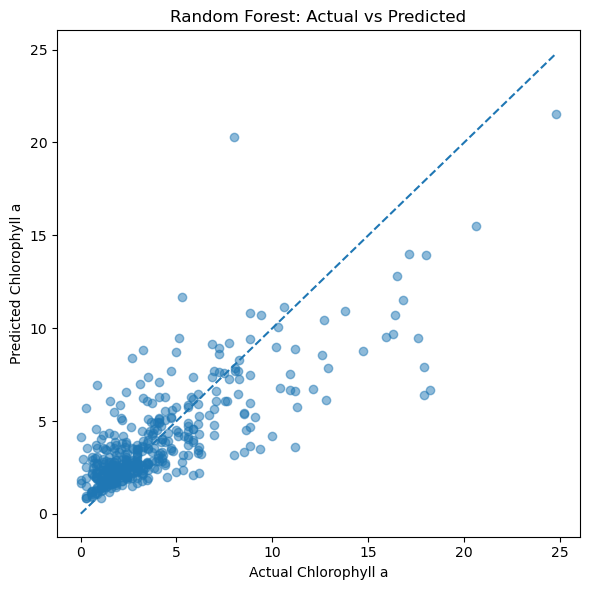

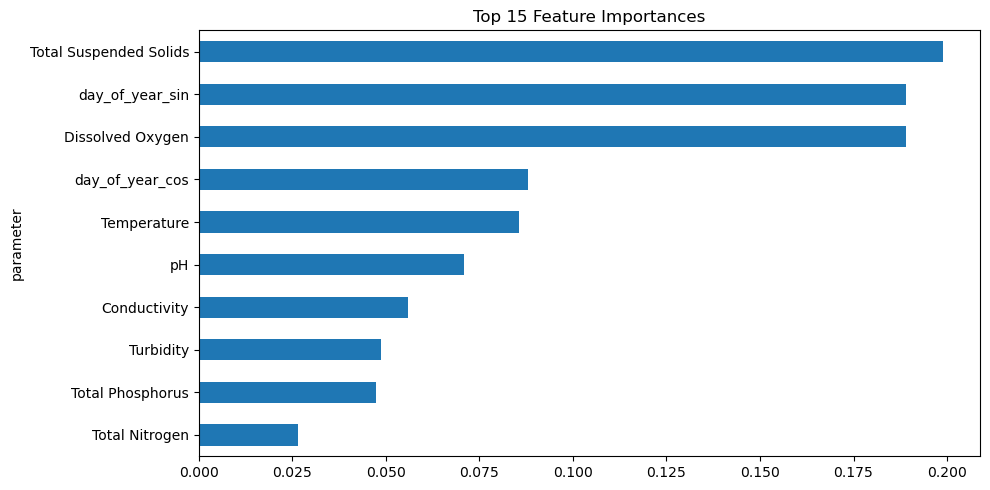

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------
# Build X and y
# ----------------------------------------------------
# Features and target
X = ml_df_imputed.copy()
y = ml_df["Chlorophyll a"]

# ----------------------------------------------------
# Train/test split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# Model + hyperparameter search
# ----------------------------------------------------
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_distributions = {
    "n_estimators": [100, 200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "bootstrap": [True, False],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

# Best model from CV
best_rf = search.best_estimator_

print("Best parameters:")
print(search.best_params_)

print(f"\nBest CV RMSE: {-search.best_score_:.4f}")

# ----------------------------------------------------
# Evaluate on held-out test set
# ----------------------------------------------------
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nHeld-out test set results:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# ----------------------------------------------------
# Actual vs predicted plot
# ----------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Chlorophyll a (ug/L)")
plt.ylabel("Predicted Chlorophyll a (ug/L)")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Feature importance
# ----------------------------------------------------
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_features.sort_values().plot(kind="barh")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [93]:
df[df['parameter']=='Chlorophyll a'][['parameter', 'value', 'units']]

,parameter,value,units
84,Chlorophyll a,21.500,ug/L
118,Chlorophyll a,11.400,ug/L
125,Chlorophyll a,6.900,ug/L
188,Chlorophyll a,1.400,ug/L
210,Chlorophyll a,7.100,ug/L
...,...,...,...
1259404,Chlorophyll a,1000000.000,ug/L
1259405,Chlorophyll a,0.929,ug/L
1259413,Chlorophyll a,0.950,ug/L
1259418,Chlorophyll a,0.511,ug/L


In [95]:
import json

# ----------------------------------------------------
# Build metadata dictionary from original JSON
# ----------------------------------------------------
metadata = {
    "dataset_name": meta.get("name"),
    "dataset_id": meta.get("id"),
    "description": meta.get("description"),
    "source_url": meta.get("url"),
    "parquet_url": meta.get("parquet_url"),
    "creator": meta.get("creator"),
    "upload_date": meta.get("upload_date"),
    "license": meta.get("licence"),
    "n_rows": int(df.shape[0]),
    "n_columns": int(df.shape[1]),
    "columns": df.columns.tolist()
}

# ----------------------------------------------------
# Convert dataframe to records
# ----------------------------------------------------
data_records = df.to_dict(orient="records")

# ----------------------------------------------------
# Final JSON structure
# ----------------------------------------------------
output = {
    "metadata": metadata,
    "data": data_records
}

# ----------------------------------------------------
# Save JSON file
# ----------------------------------------------------
output_path = "/Users/dybl4375/Desktop/water_quality_ml_dataset.json"

with open(output_path, "w") as f:
    json.dump(
        output,
        f,
        indent=2,
        default=str   # handles datetime serialization
    )

print(f"Saved to: {output_path}")

Saved to: /Users/dybl4375/Desktop/water_quality_ml_dataset.json
